In [ ]:
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 加载内置鸢尾花数据集（二分类简化）
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征方便可视化
y = iris.target

# 只做0和1两类二分类，过滤掉第三类
X = X[y != 2]
y = y[y != 2]

# 2. 划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 创建线性SVM模型
svm_linear = SVC(kernel="linear", C=1.0)
# 训练
svm_linear.fit(X_train, y_train)

# 4. 预测 + 评估
y_pred = svm_linear.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"线性SVM 测试集准确率：{acc:.2f}")

# 打印支持向量
print("支持向量数量：", svm_linear.n_support_)

线性SVM 测试集准确率：1.00
支持向量数量： [8 8]


In [ ]:
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. 加载内置鸢尾花数据集（二分类简化）
iris = datasets.load_iris()
X = iris.data[:, :2]  # 只取前两个特征方便可视化
y = iris.target

# 只做0和1两类二分类，过滤掉第三类
X = X[y != 2]
y = y[y != 2]

# 2. 划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 创建线性SVM模型
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')   # gamma='scale' 是默认值，表示使用 1 / (n_features * X.var()) 作为 gamma 值
svm_rbf.fit(X_train, y_train)

# 4. 预测 + 评估
y_pred = svm_rbf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"RBF SVM 测试集准确率：{acc:.2f}")

# 打印支持向量
print("支持向量数量：", svm_rbf.n_support_)

RBF SVM 测试集准确率：1.00
支持向量数量： [11 12]


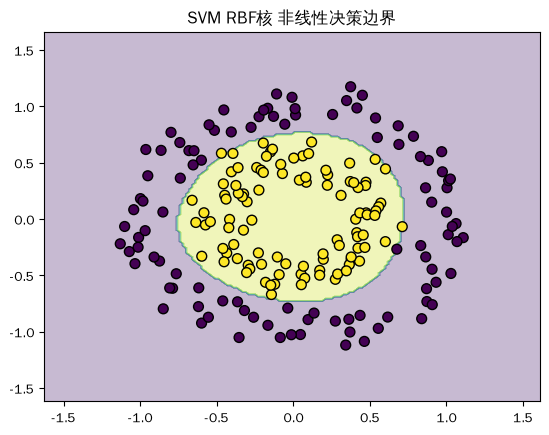

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 构造非线性数据
X, y = make_circles(200, factor=0.5, noise=0.1)     # 生成内外两个嵌套环形圆圈的二维分类数据集，用于非线性二分类模型测试。

# 训练RBF SVM
clf = SVC(kernel="rbf", C=1, gamma=2)
clf.fit(X, y)

# 绘制网格点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
# print(xx)
# print(yy)
# 预测网格类别
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
# print(Z)
Z = Z.reshape(xx.shape)

# 画图
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolors="k")
plt.title("SVM RBF核 非线性决策边界")
plt.show()